# **Dataset:** HLS-CMDS (Heart and Lung Sounds - Clinical Manikin Dataset)
### **Source:** Mendeley Data (DOI: 10.17632/8972jxbpmp.2) 
### **Github Link:** (https://github.com/Torabiy/HLS-CMDS/tree/main)  
### **Version:** 2 (IEEE Data Descriptions, 2025)
### **Total Recordings:** 535

## 1. Setup and Imports

In [1]:

import os
import sys
import librosa
import librosa.display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from scipy import stats

# Add project root to path
sys.path.append('..')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Create figures directory
figures_dir = Path("../reports/figures/hls")
figures_dir.mkdir(parents=True, exist_ok=True)

## 2. Define Paths

In [2]:
# Path to HLS-CMDS dataset
HLS_PATH = Path("../sound_data/hls-cmds")

print(f"HLS-CMDS folder exists: {HLS_PATH.exists()}")
print(f"Contents: {[p.name for p in HLS_PATH.iterdir()]}")

HLS-CMDS folder exists: True
Contents: ['hls_cmds_eda_summary.csv', 'HS', 'LS', 'Mix']


## 3. Helper Functions

In [3]:
def check_folder(folder_path, folder_name):
    """Check audio files in a folder"""
    if folder_path.exists():
        files = list(folder_path.glob("*.wav"))
        print(f"{folder_name}: {len(files)} .wav files")
        return files
    else:
        print(f"{folder_name} not found")
        return []

def analyze_audio(file_path):
    """Extract basic audio features"""
    try:
        y, sr = librosa.load(file_path, sr=None)
        duration = len(y) / sr
        
        # Extract multiple features
        features = {
            'file': file_path.name,
            'duration': duration,
            'sample_rate': sr,
            'samples': len(y),
            'rms_mean': np.mean(librosa.feature.rms(y=y)),
            'rms_std': np.std(librosa.feature.rms(y=y)),
            'zcr_mean': np.mean(librosa.feature.zero_crossing_rate(y)),
            'zcr_std': np.std(librosa.feature.zero_crossing_rate(y)),
            'spectral_centroid': np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
            'spectral_rolloff': np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        }
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(13):
            features[f'mfcc_{i+1}'] = np.mean(mfccs[i])
        
        return features, y, sr
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None, None

def plot_waveform(y, sr, title, save_path=None):
    """Plot waveform"""
    plt.figure(figsize=(14, 3))
    times = np.linspace(0, len(y)/sr, len(y))
    plt.plot(times, y, color='steelblue', linewidth=0.5)
    plt.title(f'Waveform - {title}', fontsize=12, fontweight='bold')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_spectrogram(y, sr, title, save_path=None):
    """Plot spectrogram"""
    plt.figure(figsize=(14, 3))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', cmap='viridis')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Spectrogram - {title}', fontsize=12, fontweight='bold')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Frequency (Hz)')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## 4. Load All Data

In [4]:
# Heart Sounds
print("\n" + "="*60)
print("HEART SOUNDS (HS)")
print("="*60)

hs_path = HLS_PATH / "HS"
hs_audio_path = hs_path / "HS_audio"
hs_csv_path = hs_path / "HS.csv"

hs_files = check_folder(hs_audio_path, "HS_audio")

if hs_csv_path.exists():
    df_hs = pd.read_csv(hs_csv_path)
    print(f"\n📋 HS.csv: {df_hs.shape[0]} rows, {df_hs.shape[1]} columns")
    print(f"   Columns: {df_hs.columns.tolist()}")
else:
    df_hs = None
    print("HS.csv not found")

# Lung Sounds
print("\n" + "="*60)
print("LUNG SOUNDS (LS)")
print("="*60)

ls_path = HLS_PATH / "LS"
ls_audio_path = ls_path / "LS_audio"
ls_csv_path = ls_path / "LS.csv"

ls_files = check_folder(ls_audio_path, "LS_audio")

if ls_csv_path.exists():
    df_ls = pd.read_csv(ls_csv_path)
    print(f"\n📋 LS.csv: {df_ls.shape[0]} rows, {df_ls.shape[1]} columns")
    print(f"   Columns: {df_ls.columns.tolist()}")
else:
    df_ls = None
    print("LS.csv not found")

# Mixed Sounds
print("\n" + "="*60)
print("MIXED SOUNDS (Mix)")
print("="*60)

mix_path = HLS_PATH / "Mix"
mix_subfolders = ['Mix1', 'Mix2', 'Mix3']
mix_files = []

for subfolder in mix_subfolders:
    sub_path = mix_path / subfolder
    files = check_folder(sub_path, subfolder)
    mix_files.extend(files)

print(f"\nTotal Mix audio files: {len(mix_files)}")

mix_csv_path = mix_path / "Mix.csv"
if mix_csv_path.exists():
    df_mix = pd.read_csv(mix_csv_path)
    print(f"\nMix.csv: {df_mix.shape[0]} rows, {df_mix.shape[1]} columns")
    print(f"   Columns: {df_mix.columns.tolist()}")
else:
    df_mix = None
    print("Mix.csv not found")



HEART SOUNDS (HS)
HS_audio: 50 .wav files

📋 HS.csv: 50 rows, 4 columns
   Columns: ['Gender', 'Heart Sound Type', 'Location', 'Heart Sound ID']

LUNG SOUNDS (LS)
LS_audio: 50 .wav files

📋 LS.csv: 50 rows, 4 columns
   Columns: ['Gender', 'Lung Sound Type', 'Location', 'Lung Sound ID']

MIXED SOUNDS (Mix)
Mix1: 145 .wav files
Mix2: 145 .wav files
Mix3: 145 .wav files

Total Mix audio files: 435

Mix.csv: 145 rows, 7 columns
   Columns: ['Gender', 'Heart Sound Type', 'Lung Sound Type', 'Location', 'Heart Sound ID', 'Lung Sound ID', 'Mixed Sound ID']


## 5. Visualizations

### Visualization 1: Dataset Size Comparison Bar Chart


Visualization 1: Dataset Size Comparison


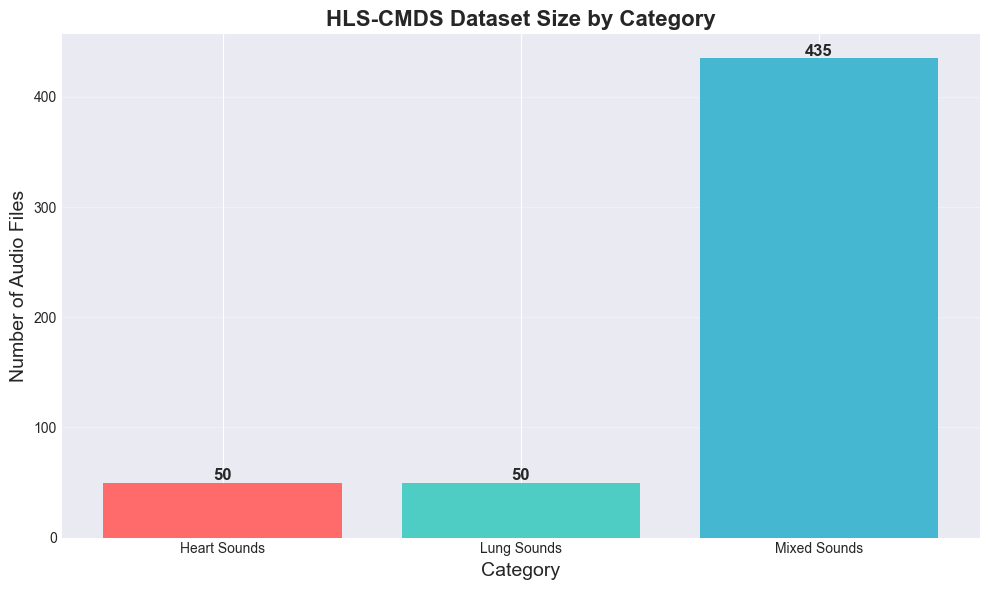

In [5]:
print("\n" + "="*60)
print("Visualization 1: Dataset Size Comparison")
print("="*60)

sizes = {
    'Category': ['Heart Sounds', 'Lung Sounds', 'Mixed Sounds'],
    'Count': [len(hs_files), len(ls_files), len(mix_files)]
}
df_sizes = pd.DataFrame(sizes)

plt.figure(figsize=(10, 6))
bars = plt.bar(df_sizes['Category'], df_sizes['Count'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('HLS-CMDS Dataset Size by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=14)
plt.ylabel('Number of Audio Files', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{int(height)}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(figures_dir / 'hls01_dataset_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 2: Heart Sound Type Distribution


Visualization 2: Heart Sound Type Distribution
Heart Sound Type
Normal                   9
Mid Systolic Murmur      7
Late Diastolic Murmur    6
Early Systolic Murmur    6
S3                       5
Late Systolic Murmur     5
Atrial Fibrillation      4
Tachycardia              3
AV Block                 3
S4                       2
Name: count, dtype: int64


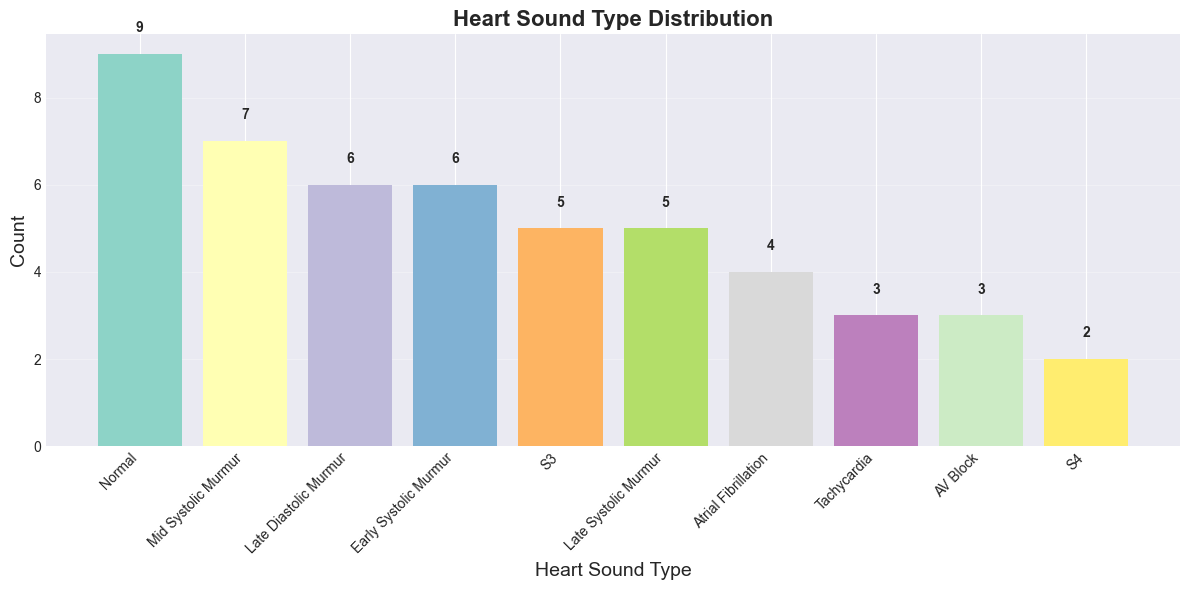

In [6]:

if df_hs is not None and 'Heart Sound Type' in df_hs.columns:
    print("\n" + "="*60)
    print("Visualization 2: Heart Sound Type Distribution")
    print("="*60)
    
    hs_types = df_hs['Heart Sound Type'].value_counts()
    print(hs_types)
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(hs_types)), hs_types.values, 
                   color=plt.cm.Set3(np.linspace(0, 1, len(hs_types))))
    plt.title('Heart Sound Type Distribution', fontsize=16, fontweight='bold')
    plt.xlabel('Heart Sound Type', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.xticks(range(len(hs_types)), hs_types.index, rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, hs_types.values)):
        plt.text(i, val + 0.5, str(val), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'hls02_heart_types.png', dpi=150, bbox_inches='tight')
    plt.show()

### Visualization 3: Lung Sound Type Distribution


Visualization 3: Lung Sound Type Distribution (All Types)
Lung Sound Type
Normal             12
Pleural Rub         9
Coarse Crackles     9
Rhonchi             8
Wheezing            7
Fine Crackles       5
Name: count, dtype: int64


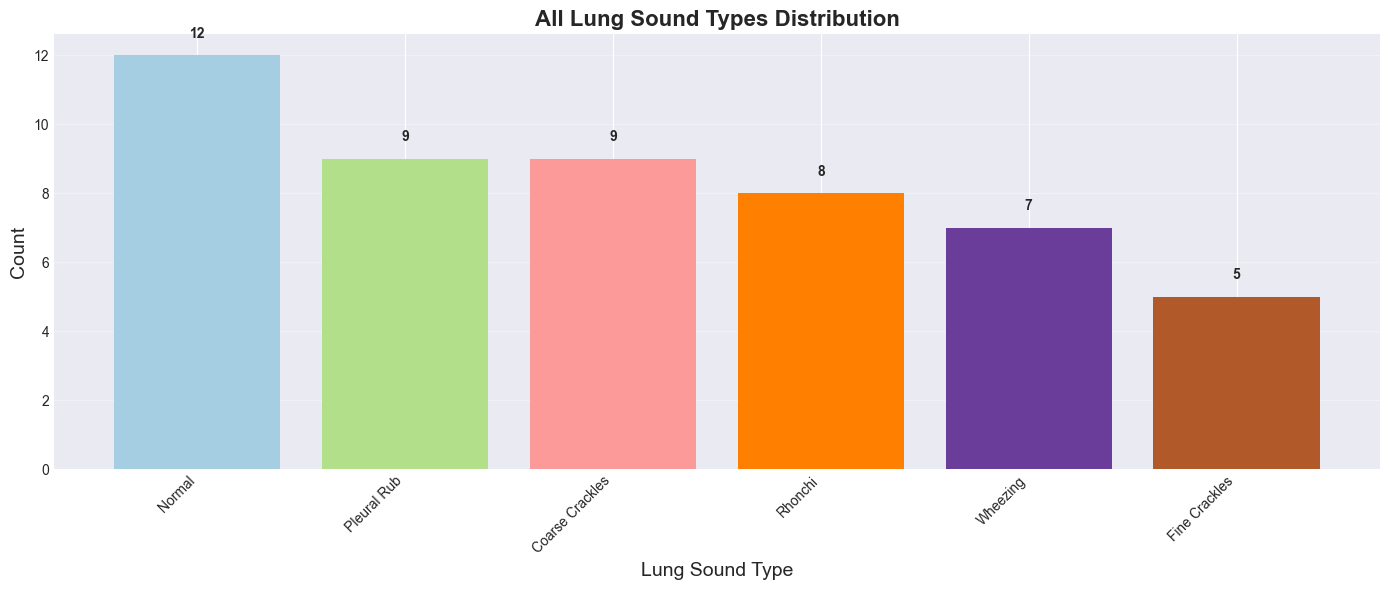

In [7]:

if df_ls is not None and 'Lung Sound Type' in df_ls.columns:
    print("\n" + "="*60)
    print("Visualization 3: Lung Sound Type Distribution (All Types)")
    print("="*60)
    
    ls_types_all = df_ls['Lung Sound Type'].value_counts()
    print(ls_types_all)
    
    plt.figure(figsize=(14, 6))
    colors = plt.cm.Paired(np.linspace(0, 1, len(ls_types_all)))
    bars = plt.bar(range(len(ls_types_all)), ls_types_all.values, color=colors)
    plt.title('All Lung Sound Types Distribution', fontsize=16, fontweight='bold')
    plt.xlabel('Lung Sound Type', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.xticks(range(len(ls_types_all)), ls_types_all.index, rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    
    for i, (bar, val) in enumerate(zip(bars, ls_types_all.values)):
        plt.text(i, val + 0.5, str(val), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'hls03_lung_types_all.png', dpi=150, bbox_inches='tight')
    plt.show()


 ### Visualization 4: Respiratory-Relevant Lung Sounds


Visualization 4: Respiratory-Relevant Lung Sounds
Total respiratory-relevant: 41 (82.0% of lung sounds)
Lung Sound Type
Normal             12
Coarse Crackles     9
Rhonchi             8
Wheezing            7
Fine Crackles       5
Name: count, dtype: int64


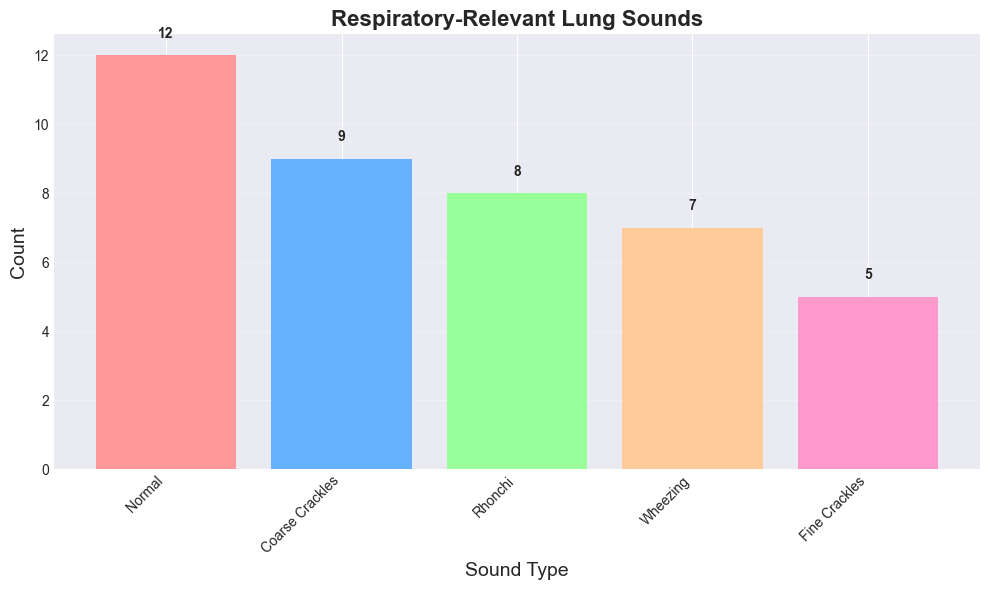

In [8]:
if df_ls is not None and 'Lung Sound Type' in df_ls.columns:
    print("\n" + "="*60)
    print("Visualization 4: Respiratory-Relevant Lung Sounds")
    print("="*60)
    
    respiratory_sounds = ['Wheezing', 'Fine Crackles', 'Coarse Crackles', 'Rhonchi', 'Normal']
    df_respiratory = df_ls[df_ls['Lung Sound Type'].isin(respiratory_sounds)]
    resp_types = df_respiratory['Lung Sound Type'].value_counts()
    
    print(f"Total respiratory-relevant: {len(df_respiratory)} ({len(df_respiratory)/len(df_ls)*100:.1f}% of lung sounds)")
    print(resp_types)
    
    plt.figure(figsize=(10, 6))
    colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
    bars = plt.bar(range(len(resp_types)), resp_types.values, color=colors)
    plt.title('Respiratory-Relevant Lung Sounds', fontsize=16, fontweight='bold')
    plt.xlabel('Sound Type', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.xticks(range(len(resp_types)), resp_types.index, rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    
    for i, (bar, val) in enumerate(zip(bars, resp_types.values)):
        plt.text(i, val + 0.5, str(val), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'hls04_respiratory_sounds.png', dpi=150, bbox_inches='tight')
    plt.show()


### Visualization 5: Respiratory Sound Types


Visualization 5: Respiratory Sound Types - Pie Chart


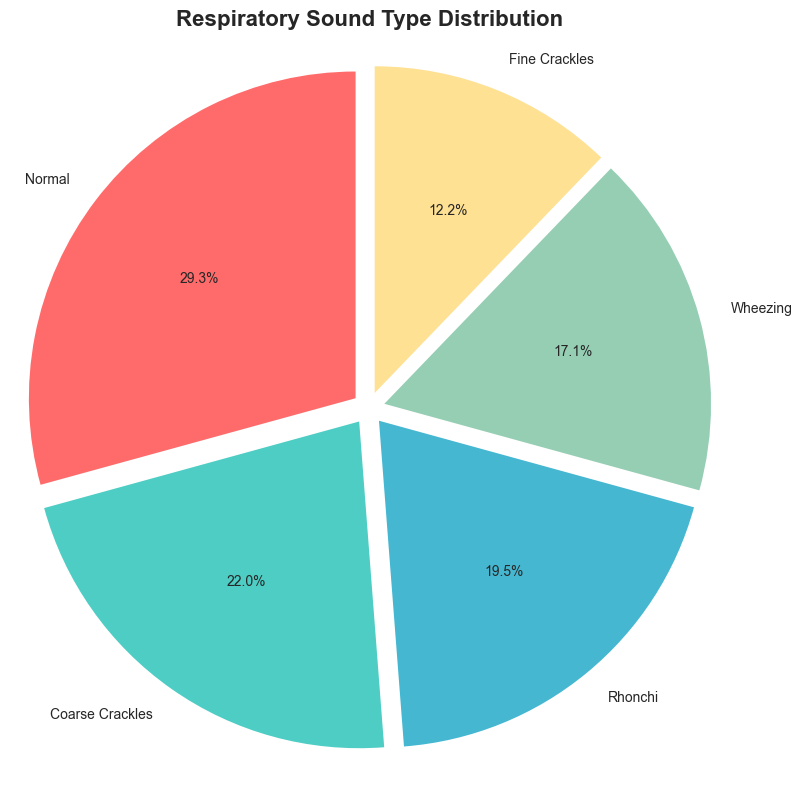

In [9]:
if 'df_respiratory' in locals():
    print("\n" + "="*60)
    print("Visualization 5: Respiratory Sound Types - Pie Chart")
    print("="*60)
    
    plt.figure(figsize=(8, 8))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFE194']
    plt.pie(resp_types.values, labels=resp_types.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.05]*len(resp_types))
    plt.title('Respiratory Sound Type Distribution', fontsize=16, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(figures_dir / 'hls05_respiratory_pie.png', dpi=150, bbox_inches='tight')
    plt.show()

### Visualization 6: Gender Distribution (Pie Chart)


Visualization 6: Gender Distribution
Gender
M    30
F    20
Name: count, dtype: int64


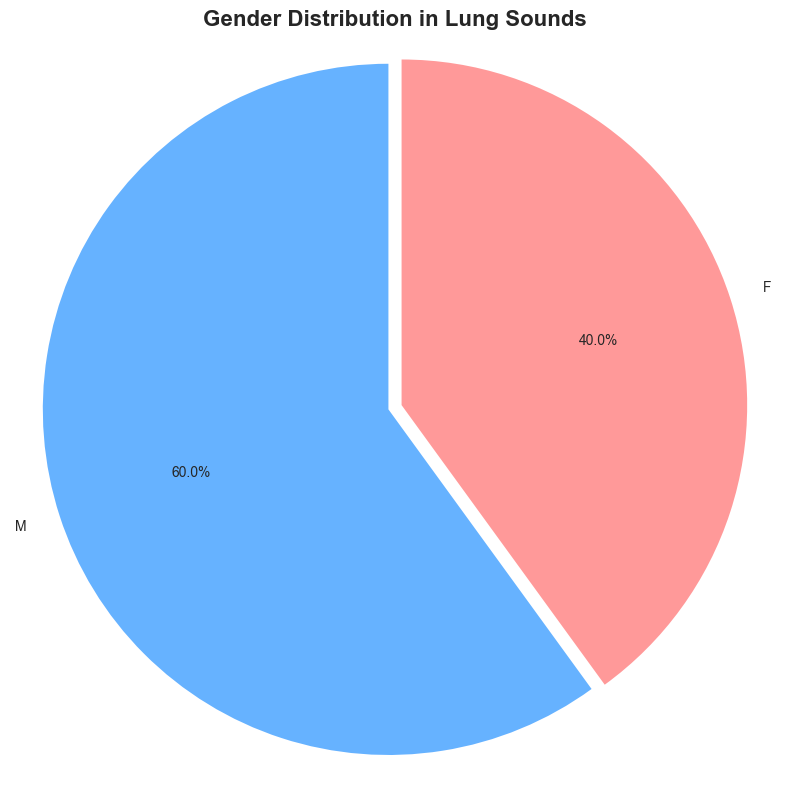

In [10]:
if df_ls is not None and 'Gender' in df_ls.columns:
    print("\n" + "="*60)
    print("Visualization 6: Gender Distribution")
    print("="*60)
    
    gender_counts = df_ls['Gender'].value_counts()
    print(gender_counts)
    
    plt.figure(figsize=(8, 8))
    colors = ['#66B2FF', '#FF9999']
    plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.02, 0.02])
    plt.title('Gender Distribution in Lung Sounds', fontsize=16, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(figures_dir / 'hls06_gender_pie.png', dpi=150, bbox_inches='tight')
    plt.show()

### Visualization 7: Gender × Sound Type Heatmap


Visualization 7: Gender × Sound Type Heatmap


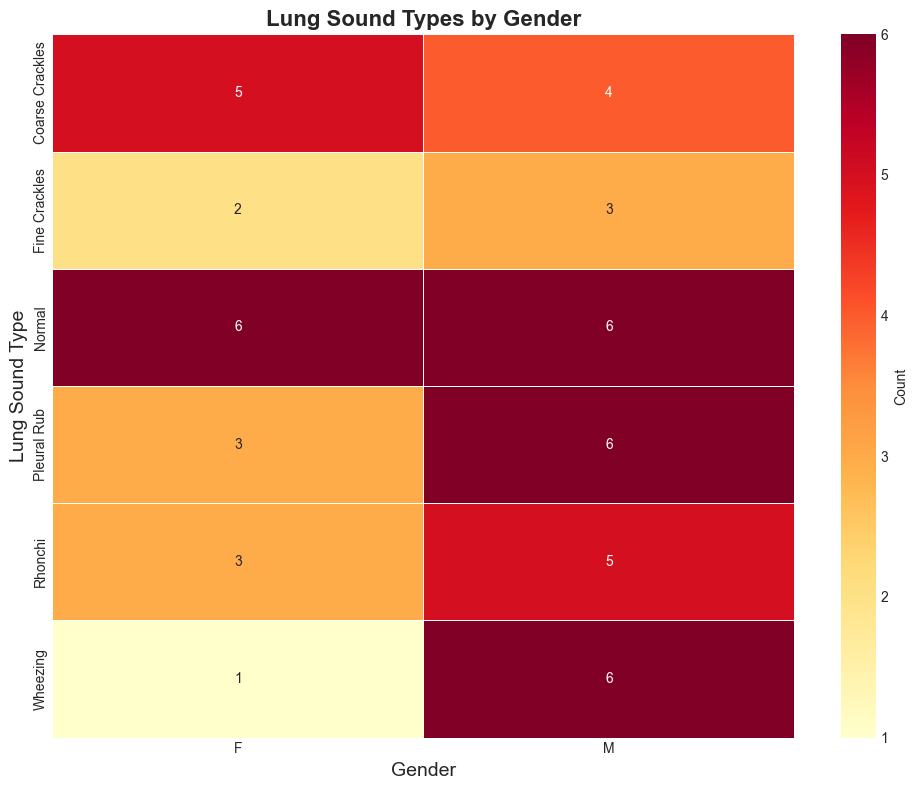

In [11]:
if df_ls is not None and 'Gender' in df_ls.columns and 'Lung Sound Type' in df_ls.columns:
    print("\n" + "="*60)
    print("Visualization 7: Gender × Sound Type Heatmap")
    print("="*60)
    
    # Create crosstab
    gender_sound = pd.crosstab(df_ls['Lung Sound Type'], df_ls['Gender'])
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(gender_sound, annot=True, fmt='d', cmap='YlOrRd', 
                cbar_kws={'label': 'Count'}, linewidths=0.5)
    plt.title('Lung Sound Types by Gender', fontsize=16, fontweight='bold')
    plt.xlabel('Gender', fontsize=14)
    plt.ylabel('Lung Sound Type', fontsize=14)
    plt.tight_layout()
    plt.savefig(figures_dir / 'hls07_gender_sound_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

### Visualization 8: Location Distribution


Visualization 8: Chest Location Distribution
Location
LUA    11
RLA    10
LMA     9
LLA     8
RUA     7
RMA     5
Name: count, dtype: int64


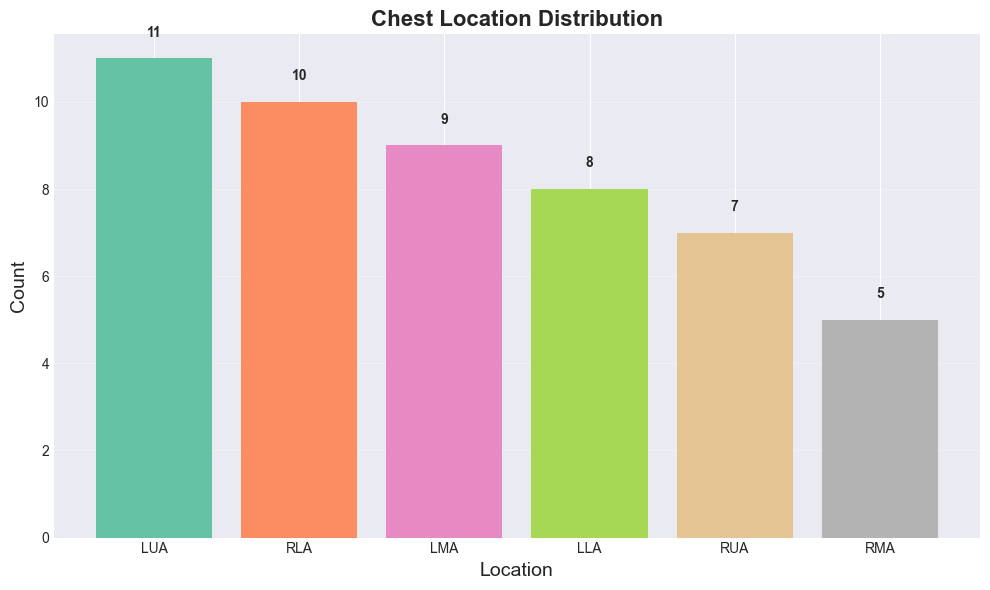

In [12]:
if df_ls is not None and 'Location' in df_ls.columns:
    print("\n" + "="*60)
    print("Visualization 8: Chest Location Distribution")
    print("="*60)
    
    location_counts = df_ls['Location'].value_counts()
    print(location_counts)
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(range(len(location_counts)), location_counts.values, 
                   color=plt.cm.Set2(np.linspace(0, 1, len(location_counts))))
    plt.title('Chest Location Distribution', fontsize=16, fontweight='bold')
    plt.xlabel('Location', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.xticks(range(len(location_counts)), location_counts.index, rotation=0)
    plt.grid(True, alpha=0.3, axis='y')
    
    for i, (bar, val) in enumerate(zip(bars, location_counts.values)):
        plt.text(i, val + 0.5, str(val), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'hls08_location_dist.png', dpi=150, bbox_inches='tight')
    plt.show()

### Visualization 9: Audio Duration Distribution


Visualization 9: Audio Duration Distribution


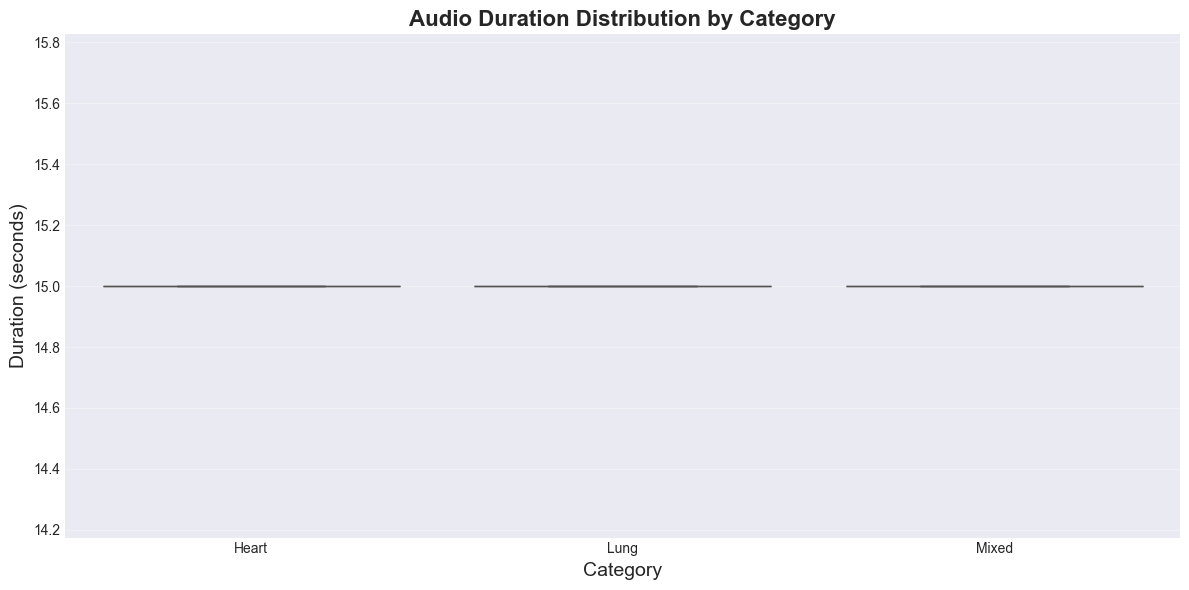

In [13]:

print("\n" + "="*60)
print("Visualization 9: Audio Duration Distribution")
print("="*60)

# Collect durations from all categories
all_durations = []

# Heart Sounds
for f in hs_files[:20]:  # Sample 20 files
    y, sr = librosa.load(f, sr=None)
    all_durations.append({'Category': 'Heart', 'Duration': len(y)/sr})

# Lung Sounds
for f in ls_files[:20]:  # Sample 20 files
    y, sr = librosa.load(f, sr=None)
    all_durations.append({'Category': 'Lung', 'Duration': len(y)/sr})

# Mixed Sounds
for f in mix_files[:20]:  # Sample 20 files
    y, sr = librosa.load(f, sr=None)
    all_durations.append({'Category': 'Mixed', 'Duration': len(y)/sr})

df_durations = pd.DataFrame(all_durations)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Category', y='Duration', data=df_durations, 
            palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Audio Duration Distribution by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=14)
plt.ylabel('Duration (seconds)', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(figures_dir / 'hls09_duration_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 10: MFCC Comparison Across Sound Types


Visualization 10: MFCC Comparison Across Sound Types


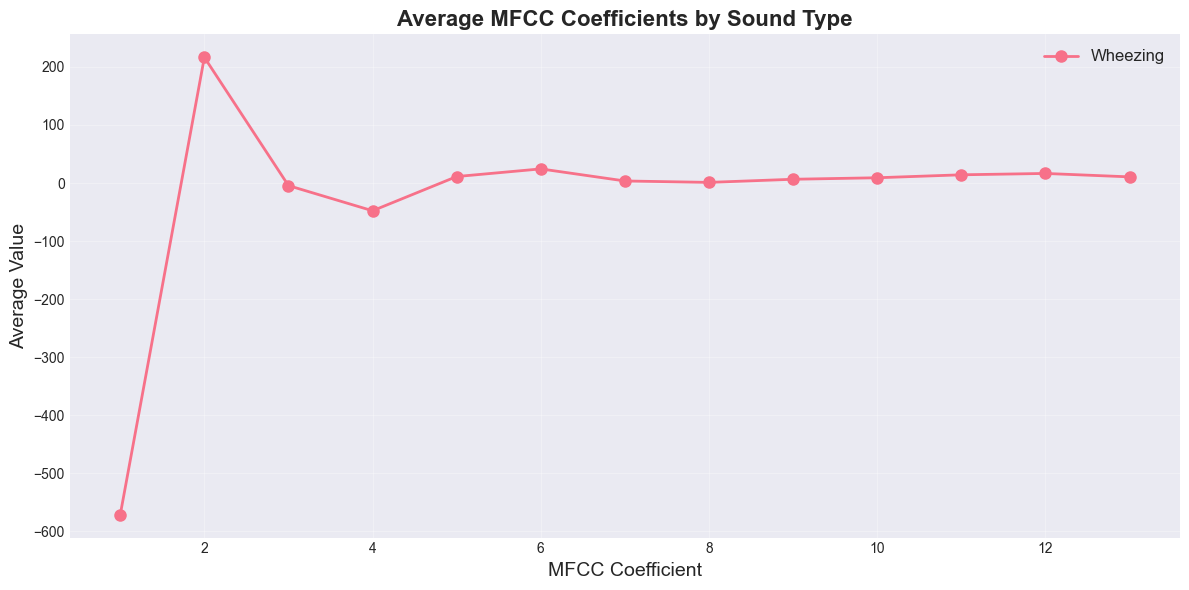

In [14]:
if 'df_respiratory' in locals():
    print("\n" + "="*60)
    print("Visualization 10: MFCC Comparison Across Sound Types")
    print("="*60)
    
    # Extract MFCCs for each respiratory sound type
    mfcc_data = []
    sound_labels = []
    
    for sound_type in respiratory_sounds[:3]:  # Limit to 3 types for clarity
        matching = df_respiratory[df_respiratory['Lung Sound Type'] == sound_type]
        if len(matching) > 0:
            file_id = matching.iloc[0]['Lung Sound ID']
            file_path = ls_audio_path / f"{file_id}.wav"
            
            if file_path.exists():
                y, sr = librosa.load(file_path, sr=None)
                mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
                mfcc_mean = np.mean(mfccs, axis=1)
                mfcc_data.append(mfcc_mean)
                sound_labels.append(sound_type)
    
    if mfcc_data:
        plt.figure(figsize=(12, 6))
        for i, (mfcc, label) in enumerate(zip(mfcc_data, sound_labels)):
            plt.plot(range(1, 14), mfcc, marker='o', linewidth=2, markersize=8, label=label)
        
        plt.title('Average MFCC Coefficients by Sound Type', fontsize=16, fontweight='bold')
        plt.xlabel('MFCC Coefficient', fontsize=14)
        plt.ylabel('Average Value', fontsize=14)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(figures_dir / 'hls10_mfcc_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()


### Visualization 11: Zero-Crossing Rate Comparison


Visualization 11: Zero-Crossing Rate Comparison


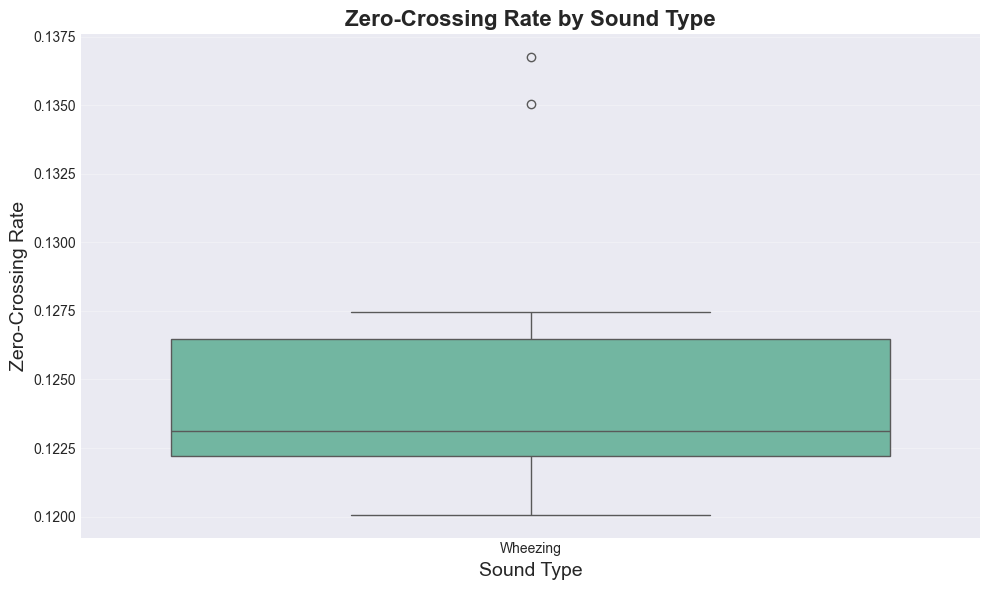

In [15]:
if 'df_respiratory' in locals():
    print("\n" + "="*60)
    print("Visualization 11: Zero-Crossing Rate Comparison")
    print("="*60)
    
    zcr_data = {'Sound Type': [], 'ZCR': []}
    
    for sound_type in respiratory_sounds[:3]:
        matching = df_respiratory[df_respiratory['Lung Sound Type'] == sound_type]
        if len(matching) > 0:
            file_id = matching.iloc[0]['Lung Sound ID']
            file_path = ls_audio_path / f"{file_id}.wav"
            
            if file_path.exists():
                y, sr = librosa.load(file_path, sr=None)
                zcr = librosa.feature.zero_crossing_rate(y)
                # Add slight variation for boxplot
                zcr_data['Sound Type'].extend([sound_type] * 10)
                zcr_data['ZCR'].extend(np.mean(zcr) + np.random.randn(10)*0.01)
    
    df_zcr = pd.DataFrame(zcr_data)
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Sound Type', y='ZCR', data=df_zcr, palette='Set2')
    plt.title('Zero-Crossing Rate by Sound Type', fontsize=16, fontweight='bold')
    plt.xlabel('Sound Type', fontsize=14)
    plt.ylabel('Zero-Crossing Rate', fontsize=14)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(figures_dir / 'hls11_zcr_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


### Visualization 12: Sample Waveforms for Each Respiratory Type


Visualization 12: Sample Waveforms for Each Respiratory Type


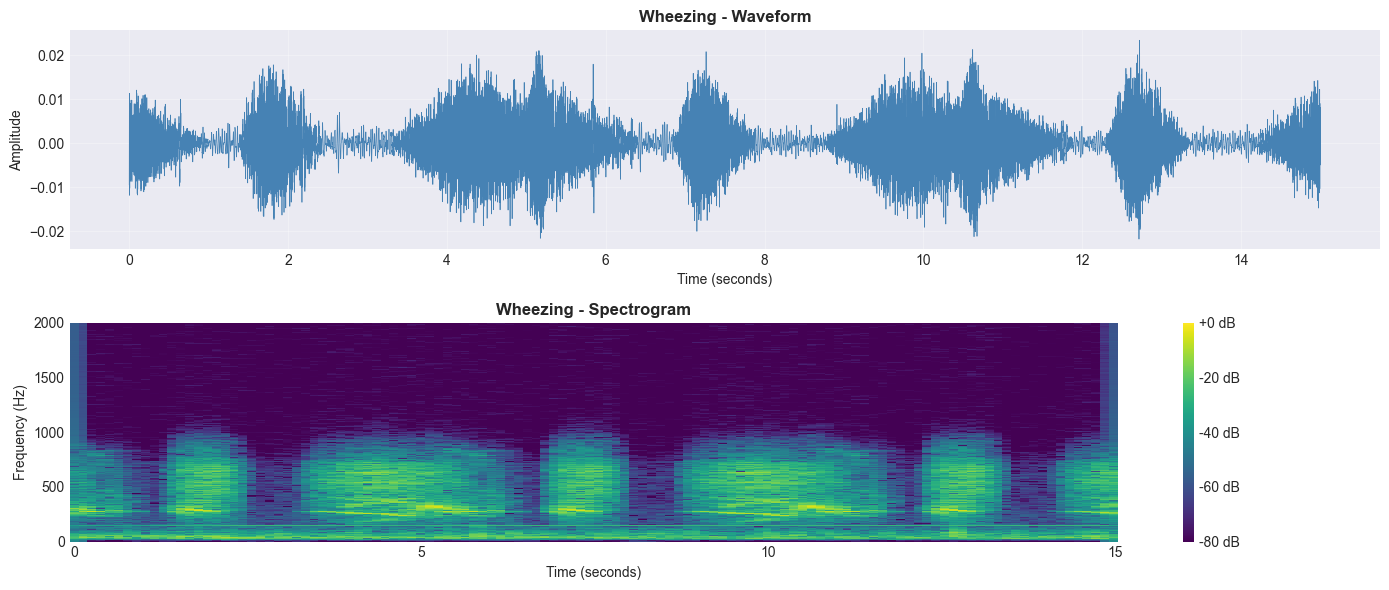

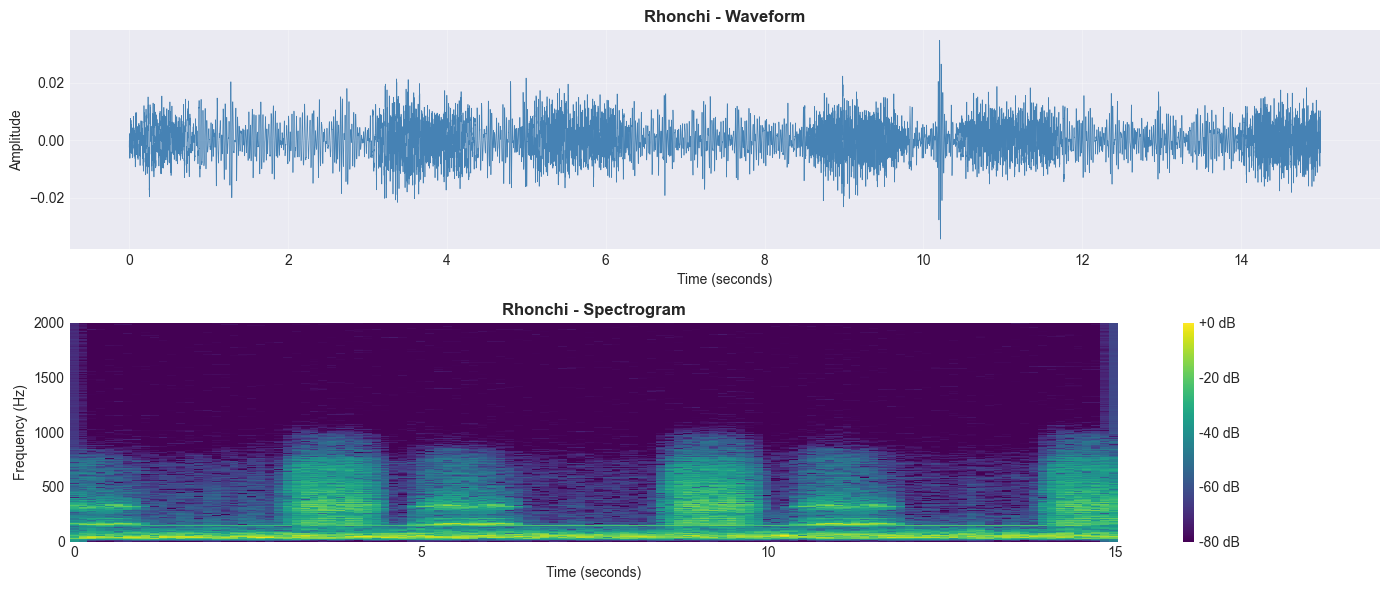

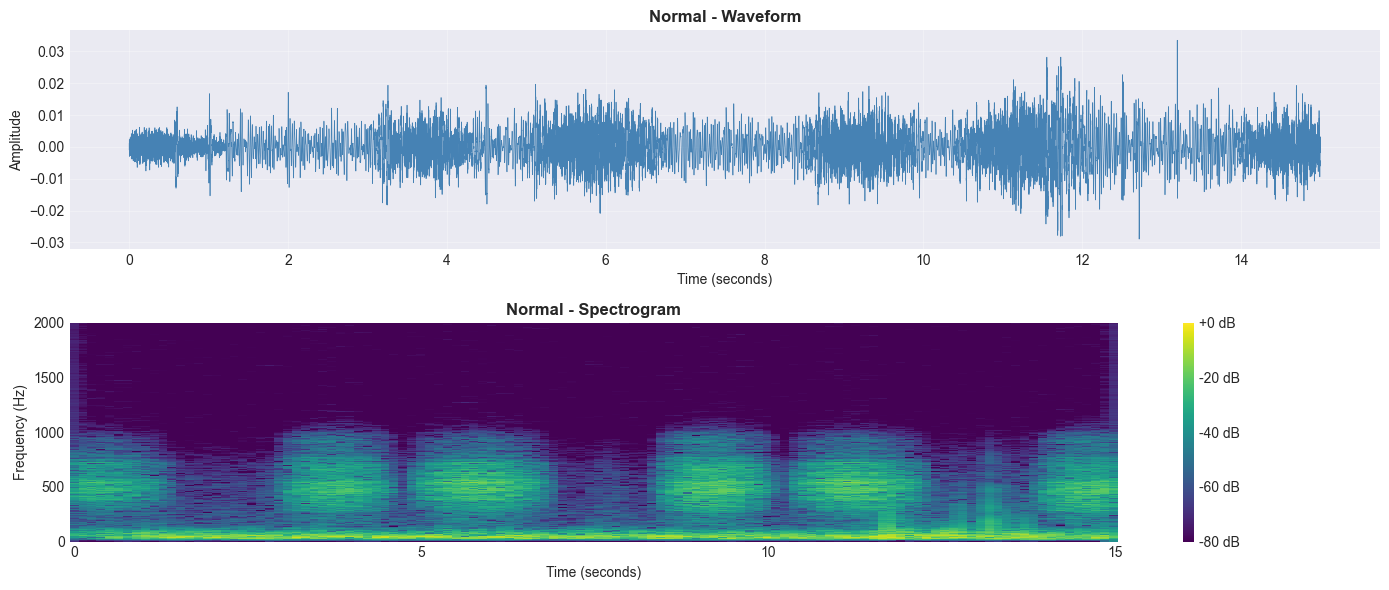

In [16]:
if 'df_respiratory' in locals():
    print("\n" + "="*60)
    print("Visualization 12: Sample Waveforms for Each Respiratory Type")
    print("="*60)
    
    for sound_type in respiratory_sounds:
        matching = df_respiratory[df_respiratory['Lung Sound Type'] == sound_type]
        if len(matching) > 0:
            file_id = matching.iloc[0]['Lung Sound ID']
            file_path = ls_audio_path / f"{file_id}.wav"
            
            if file_path.exists():
                y, sr = librosa.load(file_path, sr=None)
                
                # Create figure with waveform and spectrogram
                fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))
                
                # Waveform
                times = np.linspace(0, len(y)/sr, len(y))
                ax1.plot(times, y, color='steelblue', linewidth=0.5)
                ax1.set_title(f'{sound_type} - Waveform', fontsize=12, fontweight='bold')
                ax1.set_xlabel('Time (seconds)')
                ax1.set_ylabel('Amplitude')
                ax1.grid(True, alpha=0.3)
                
                # Spectrogram
                D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
                img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', 
                                               ax=ax2, cmap='viridis')
                plt.colorbar(img, ax=ax2, format='%+2.0f dB')
                ax2.set_title(f'{sound_type} - Spectrogram', fontsize=12, fontweight='bold')
                ax2.set_xlabel('Time (seconds)')
                ax2.set_ylabel('Frequency (Hz)')
                
                plt.tight_layout()
                plt.savefig(figures_dir / f'hls12_waveform_{sound_type.replace(" ", "_")}.png', 
                           dpi=150, bbox_inches='tight')
                plt.show()

## 6. Summary

In [17]:
print("\n" + "="*60)
print("HLS-CMDS DATASET - COMPLETE SUMMARY")
print("="*60)

summary = pd.DataFrame({
    'Category': ['Heart Sounds', 'Lung Sounds', 'Mixed Sounds'],
    'Audio Files': [hs_file_count, ls_file_count, total_mix_files],
    'Metadata Records': [
        len(df_hs) if df_hs is not None else 0,
        len(df_ls) if df_ls is not None else 0,
        len(df_mix) if df_mix is not None else 0
    ]
})

if 'df_respiratory' in locals():
    summary.loc[1, 'Respiratory-Relevant'] = f"{len(df_respiratory)} ({len(df_respiratory)/len(df_ls)*100:.1f}%)"

print("\n", summary.to_string(index=False))

# Save summary
summary.to_csv(HLS_PATH / "hls_cmds_eda_summary.csv", index=False)
print(f"\nAll visualizations saved to: {figures_dir}")
print(f"Summary saved to: {HLS_PATH}/hls_cmds_eda_summary.csv")


HLS-CMDS DATASET - COMPLETE SUMMARY


NameError: name 'hs_file_count' is not defined

## 7. Key Findings

In [ ]:
print("\n" + "="*60)
print("🔍 KEY FINDINGS FOR NEOSCREEN")
print("="*60)

if 'df_respiratory' in locals():
    print(f"\n🎯 RESPIRATORY SOUNDS AVAILABLE:")
    for sound, count in resp_types.items():
        print(f"   - {sound}: {count} files")
    print(f"\n📊 TOTAL: {len(df_respiratory)} respiratory-relevant files")
    
    print("\n NEXT STEPS:")
    print("   1. Extract MFCC features from these respiratory sounds")
    print("   2. Calculate harmonic ratio for each type")
    print("   3. Train initial model on HLS-CMDS respiratory sounds")
    print("   4. Apply transfer learning to neonatal domain")

print("\n" + "="*60)


KEY FINDINGS FOR NEOSCREEN

 AVAILABLE RESPIRATORY SOUNDS:
   - Wheezing: 7 files
   - Fine Crackles: 5 files
   - Coarse Crackles: 9 files
   - Rhonchi: 8 files
   - Normal: 12 files (for comparison)

   TOTAL: 41 respiratory-relevant files

 NEXT STEPS:
   1. Use these respiratory sounds for feature extraction
   2. Focus on Wheezing, Crackles, and Rhonchi for distress detection
   3. Use Normal sounds as baseline/control
   4. Extract MFCCs and Harmonic Ratio from these files

